# Breast Cancer Diagnosis
## Import packages/modules

In [1]:
from mistic import combined_rank, cvSet, kernelWrapper, paramSet, perDiff, score_svc, svmSet

import matplotlib.pyplot as plt   
import numpy as np
import pandas as pd
import copy

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

## Import dataset

In [2]:
# Import dataset
dataTable = pd.read_csv("wdbc.data", sep = ",",header=None) 
properties = ["Radius","Texture","Perimeter","Area","Smoothness","Compactness","Concavity","Concave Points","Symmetry","Fractal Dimension"]
names = ["ID", "Diagnosis"]+[p+" mean" for p in properties]+[p+" SE" for p in properties]+[p+" worst" for p in properties]
dataTable.columns = pd.Index(names)
dataTable

,ID,Diagnosis,Radius mean,Texture mean,Perimeter mean,Area mean,Smoothness mean,Compactness mean,Concavity mean,Concave Points mean,...,Radius worst,Texture worst,Perimeter worst,Area worst,Smoothness worst,Compactness worst,Concavity worst,Concave Points worst,Symmetry worst,Fractal Dimension worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


## Scale data and setup test set

In [3]:
X = dataTable.copy()
X.drop(columns=['ID','Diagnosis'],inplace=True)
scaler = StandardScaler()
scaler.fit(X)

X_all = scaler.transform(X)
y_all = dataTable.iloc[:,1]

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, 
                                                    stratify = y_all, 
                                                    random_state= 0, 
                                                    test_size= 1/5)

## Define cross validation sets

In [4]:
cv_set = cvSet(X = X_train, y = y_train.values)
cv_set.classification(num_sets = 5)

## Initialize SVC model and parameter grids

In [5]:
svc = SVC(kernel = 'precomputed', class_weight="balanced", probability=False, tol = 1e-12)

C_range = [2**x for x in range(-2,5)]
gamma_range = [2**x for x in range(-9,1)]

parameter_grid = []
for cost in C_range:
    for gamma in gamma_range:
        parameter_grid.append(paramSet(model={"C": cost},kernel={"gamma": gamma}))

## Feature Selection

In [17]:
kernel_type = "rbf"

rank_weights = [0.75,0.8,0.85,0.9,0.95,1.0]

svm_set_ranks = []
for i in range(len(rank_weights)):
    print(f"Rank weight: {rank_weights[i]:.2f}")
    svm_set_ranks.append(svmSet(svc, cv_set,
                                score_method = score_svc().score,
                                kernel = kernelWrapper(type = kernel_type),
                                separate_feature_sets = True,
                                separate_parameters = True))

    svm_set_ranks[i].greedy_forward_selection(parameter_grid = parameter_grid,
                                              addition_factor = 0.1,
                                              max_features = 15,
                                              feature_ranker = combined_rank(weight=rank_weights[i]).compute,
                                              set_for_rank = "sample",
                                              tune_models_each_step = True)

Rank weight: 0.75
Number of Features: 1, Score: 0.941
Number of Features: 3, Score: 0.979
Number of Features: 5, Score: 0.997
Number of Features: 7, Score: 0.992
Number of Features: 9, Score: 0.992
Number of Features: 11, Score: 0.990
Number of Features: 12, Score: 0.992
Number of Features: 13, Score: 0.994
Number of Features: 14, Score: 0.992
Number of Features: 15, Score: 0.994
Number of Features: 30, Score: 0.995
Rank weight: 0.80
Number of Features: 1, Score: 0.941
Number of Features: 3, Score: 0.979
Number of Features: 5, Score: 0.997
Number of Features: 7, Score: 0.990
Number of Features: 9, Score: 0.992
Number of Features: 11, Score: 0.990
Number of Features: 12, Score: 0.992
Number of Features: 13, Score: 0.991
Number of Features: 14, Score: 0.991
Number of Features: 15, Score: 0.995
Number of Features: 30, Score: 0.995
Rank weight: 0.85
Number of Features: 1, Score: 0.941
Number of Features: 3, Score: 0.979
Number of Features: 5, Score: 0.997
Number of Features: 7, Score: 0.99

## Feature Selection Performance Curves

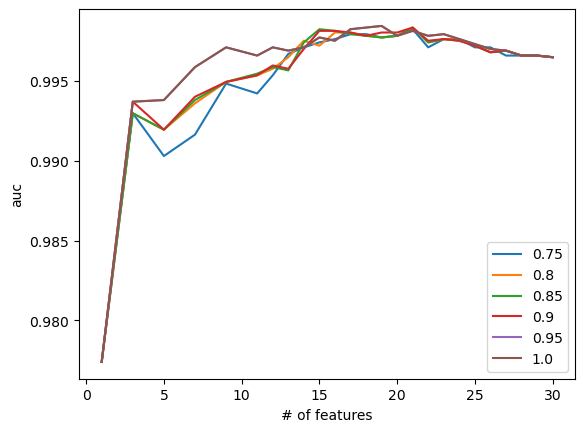

In [7]:
for i in range(len(rank_weights)):
    svm_set_ranks[i].plot_performance(metric="auc")

plt.legend(labels=rank_weights)

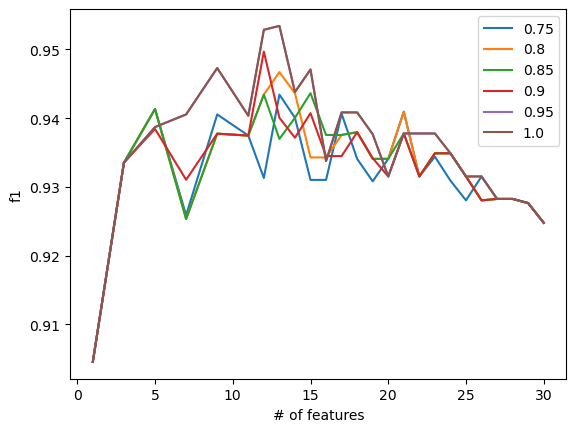

In [8]:
for i in range(len(rank_weights)):
    svm_set_ranks[i].plot_performance(metric="f1")

plt.legend(labels=rank_weights)

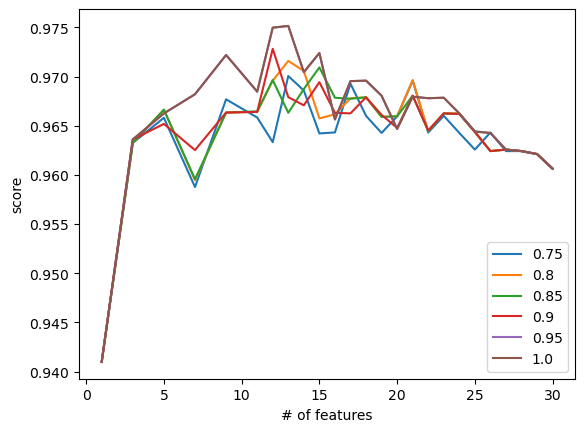

In [9]:
for i in range(len(rank_weights)):
    svm_set_ranks[i].plot_performance(metric="score")

plt.legend(labels=rank_weights)

## Feature Selection Enrichment Scores

In [10]:
enrich_score = []
for i in range(len(rank_weights)):
    enrich_score.append(svm_set_ranks[i].enrichment_score())

selected_run = enrich_score.index(max(enrich_score))

enrich_score

[0.931841907045941,
 0.9324714002725286,
 0.9324184156210807,
 0.9324629367550841,
 0.9343594399414707,
 0.9343594399414707]

## Best Model Blind Set Performance

In [11]:
from sklearn.metrics import roc_auc_score, confusion_matrix

decision_values = svm_set_ranks[selected_run].decision_function(X_test)
y_pred = svm_set_ranks[selected_run].predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision = tp/(tp+fp)
recall = tp/(tp+fn)
f1 = 2*precision*recall/(precision+recall)

auc = roc_auc_score(y_test, decision_values)
            
blind_results = {'rank_weights': rank_weights[selected_run], 'number_features': len(svm_set_ranks[selected_run].features[0]), 'f1': f1, 'auc': auc}

blind_results

{'rank_weights': 0.95,
 'number_features': 9,
 'f1': 0.898876404494382,
 'auc': 0.9923941798941798}

## Integrated Gradients Atrributions

In [12]:
# The result object keeps attribution columns aligned with their feature names
# and stores the class labels used by the heatmap annotation strip.
ig_result = svm_set_ranks[selected_run].explain_integrated_gradients(
    X_test,
    feature_names=X.columns,
    target=np.asarray(y_test),
    model_index=None,
)

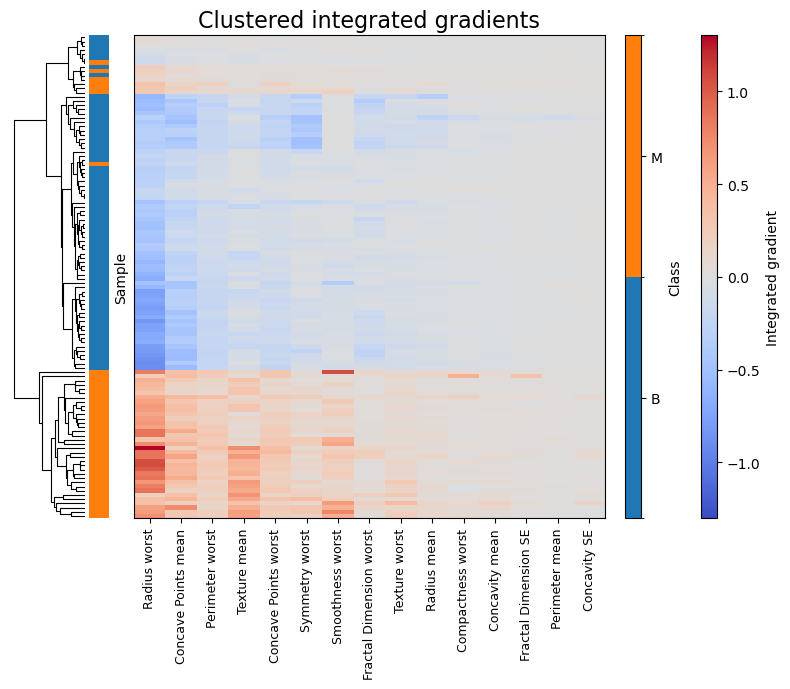

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
ig_result.heatmap(
    ax=ax,
    cluster=True,
    cmap="coolwarm",
    imshow_kwargs={"rasterized": True},
    target_strip_width=0.20,
    strip_pad=0.25,
    colorbar_width=0.16,
    colorbar_pad=0.2,
    colorbar_gap=0.6,
)
ax.set_title("Clustered integrated gradients", fontsize=16)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()


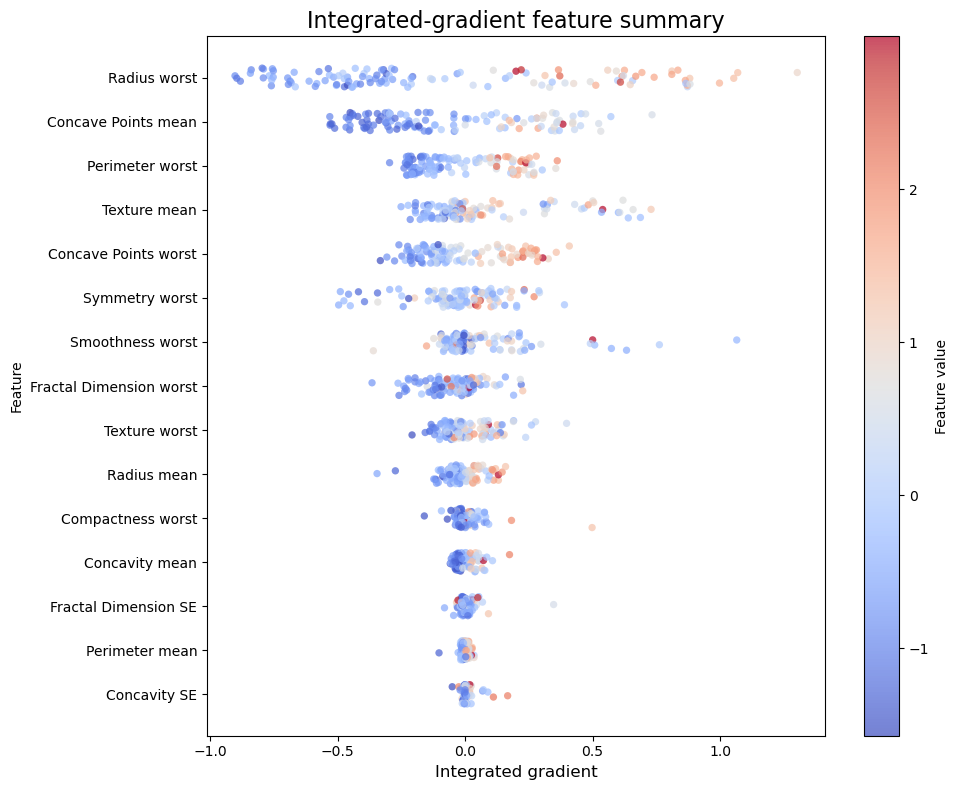

In [14]:
# Supplying an axes object leaves figure size, typography, and other styling
# under the caller's control. The returned axes can be edited further.
fig, ax = plt.subplots(figsize=(10, 8))
ig_result.summary_plot(
    ax=ax,
    max_features=20,
    cmap="coolwarm",
    random_state=0,
    scatter_kwargs={"s": 28, "alpha": 0.7, "edgecolors": "none"},
)
ax.set_title("Integrated-gradient feature summary", fontsize=16)
ax.set_xlabel("Integrated gradient", fontsize=12)
ax.tick_params(labelsize=10)
plt.tight_layout()


<Axes: title={'center': 'Interaction score: 0.643'}, xlabel='Concave Points mean', ylabel='Integrated gradient for Concave Points mean'>

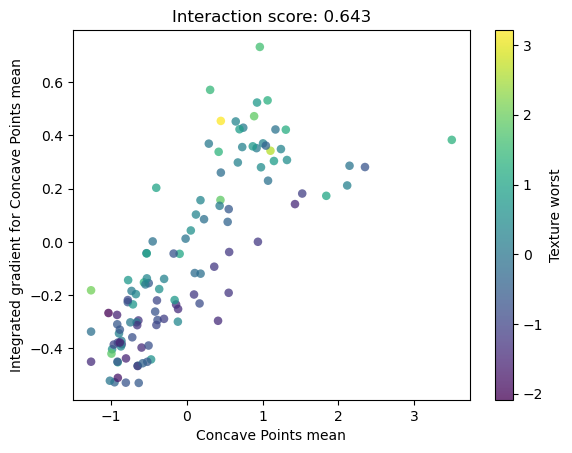

In [15]:
# With no feature arguments, the result uses its attribution-based interaction
# heuristic to nominate a pair for inspection.
ig_result.interaction_plot(
    scatter_kwargs={"s": 38, "alpha": 0.75, "edgecolors": "none"},
)